# LoRA
This notebook compare CLIP, CLIP + LoRA, CoCoOp, and CoCoOp + LoRA (1, 4, 8, and 16 shots) on caltech-101 dataset

## 1. Install Dependencies

In [1]:
# Install required packages
!pip install git+https://github.com/openai/CLIP.git
!pip install tqdm

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ekdtstsf
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ekdtstsf
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=7f8ba880bfdbba6755977fb22e2c9143d9153f27f2110f1fa34e3105c0dddd4a
  Stored in directory: /tmp/pip-ephem-wheel-cache-8b7cdaue/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


## 2. Imports

In [2]:
import os
import json
import math
import random
from dataclasses import dataclass
from typing import List

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import clip
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import time

print(f"PyTorch  : {torch.__version__}")
print(f"CLIP     : loaded")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = (DEVICE == "cuda")
print(f"Device   : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
CLIP     : loaded
Device   : cuda
GPU      : Tesla T4


## 3. Paths, Registry and Global Config

In [3]:
# Path
DATASET_DIR = "/kaggle/input/datasets/ramitachongcham/"
OUTPUT_DIR = "/kaggle/working/output"
PLOTS_DIR   = os.path.join(OUTPUT_DIR, "plots")
CKPT_DIR    = os.path.join(OUTPUT_DIR, "checkpoints")
CSV_DIR     = os.path.join(OUTPUT_DIR, "csv")

for d in [OUTPUT_DIR, PLOTS_DIR, CKPT_DIR, CSV_DIR]:
    os.makedirs(d, exist_ok=True)

# Dataset registry
REGISTRY = {
    "caltech-101": {
        "drive_subpath":  "caltech-101/caltech-101",
        "split_json":     "split_zhou_Caltech101.json",
        "images_subpath": "101_ObjectCategories",
    }
}

# Experiment settings
DATASETS    = ["caltech-101"]
SHOTS_LIST  = [1, 4, 8, 16]
MODEL_NAME  = "ViT-B/16"
SEED        = 1

# Hyperparameters
N_CTX        = 4
CTX_INIT     = "a photo of a"
LR           = 0.001 # paper learning rate start from 0.001
WEIGHT_DECAY = 5e-4
EPOCHS       = 20 # number of epoch according to the paper
BATCH_SIZE   = 4
NUM_WORKERS  = 0
print("Config loaded.")
print(f"  Datasets   : {DATASETS}")
print(f"  Shots      : {SHOTS_LIST}")
print(f"  Backbone   : {MODEL_NAME}")
print(f"  Epochs     : {EPOCHS}")
print(f"  LR         : {LR}")
print(f"  n_ctx      : {N_CTX}  ctx_init: '{CTX_INIT}'")
print(f"  DEVICE     : {DEVICE}")
print(f"  Output dir : {OUTPUT_DIR}")

Config loaded.
  Datasets   : ['caltech-101']
  Shots      : [1, 4, 8, 16]
  Backbone   : ViT-B/16
  Epochs     : 20
  LR         : 0.001
  n_ctx      : 4  ctx_init: 'a photo of a'
  DEVICE     : cuda
  Output dir : /kaggle/working/output


## 4. Reproducibility

In [4]:
def set_seed(seed: int = 1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 1


## 5. Dataset Split Utilities

In [5]:
@dataclass
class Sample:
    """Represents one image-label pair with absolute path stored."""
    impath:    str
    label:     int
    classname: str

In [6]:
def get_dataset_paths(dataset_name: str):
    cfg          = REGISTRY[dataset_name]
    dataset_root = os.path.join(DATASET_DIR, cfg["drive_subpath"])
    split_path   = os.path.join(dataset_root, cfg["split_json"])
    image_root   = os.path.join(dataset_root, cfg["images_subpath"])
    return dataset_root, split_path, image_root

def read_split_json(dataset_name: str):
    """Load Zhou-format split JSON and return (train, val, test) lists of Sample."""
    _, split_path, image_root = get_dataset_paths(dataset_name)
    assert os.path.exists(split_path), f"Split JSON not found: {split_path}"
    assert os.path.exists(image_root), f"Image root not found: {image_root}"

    with open(split_path, "r") as f:
        split = json.load(f)

    def convert(items):
        out = []
        for relpath, label, classname in items:
            impath = os.path.join(image_root, relpath)
            out.append(Sample(impath=impath, label=int(label), classname=classname))
        return out

    return convert(split["train"]), convert(split["val"]), convert(split["test"])

In [7]:
def fewshot_subset(items: List[Sample], num_shots: int, seed: int = 1) -> List[Sample]:
    """Return exactly num_shots items per class (random sample)."""
    rng      = random.Random(seed)
    by_label = {}
    for x in items:
        by_label.setdefault(x.label, []).append(x)

    out = []
    for _, group in by_label.items():
        group = group.copy()
        rng.shuffle(group)
        out.extend(group[:num_shots])
    return out

def subsample_classes(train, val, test, subsample: str = "all"):
    """
    Split classes into Base (first half) and New (second half).

    - 'base' : keep only base classes
    - 'new' : keep only new classes
    - 'all' : keep all classes

    """
    assert subsample in ["all", "base", "new"]
    if subsample == "all":
        return train, val, test

    labels   = sorted({x.label for x in train})
    m        = math.ceil(len(labels) / 2)
    selected = labels[:m] if subsample == "base" else labels[m:]
    relabeler = {old: new for new, old in enumerate(selected)}

    def filter_relabel(items):
        return [
            Sample(impath=x.impath,
                   label=relabeler[x.label],
                   classname=x.classname)
            for x in items if x.label in selected
        ]

    return filter_relabel(train), filter_relabel(val), filter_relabel(test)

def build_splits(dataset_name: str, num_shots: int,
                 seed: int = 1, subsample: str = "all"):
    """
    Full pipeline: load JSON → few-shot sample → class subsample.
    Val is capped at min(num_shots, 4) per class to stay proportional to training.
    """
    train, val, test = read_split_json(dataset_name)

    if num_shots >= 1:
        train = fewshot_subset(train, num_shots=num_shots,       seed=seed)
        val   = fewshot_subset(val,   num_shots=min(num_shots, 4), seed=seed)

    train, val, test = subsample_classes(train, val, test, subsample)
    return train, val, test

## 6. PyTorch Dataset and DataLoaders

In [8]:
class ImageClassificationDataset(Dataset):
    """Returns rich dict with image, label, classname, and impath for debugging."""

    def __init__(self, items: List[Sample], transform):
        self.items     = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int):
        item  = self.items[idx]
        image = Image.open(item.impath).convert("RGB")
        image = self.transform(image)
        return {
            "image":     image,
            "label":     item.label,
            "classname": item.classname,
            "impath":    item.impath,
        }

def collate_fn(batch):
    return {
        "image":     torch.stack([x["image"] for x in batch]),
        "label":     torch.tensor([x["label"] for x in batch], dtype=torch.long),
        "classname": [x["classname"] for x in batch],
        "impath":    [x["impath"]    for x in batch],
    }

## 7. Load CLIP Backbone

In [9]:
_, preprocess = clip.load(MODEL_NAME, device=DEVICE, jit=False)

def load_clip_model():
    clip_model = clip.load(MODEL_NAME, device=DEVICE, jit=False)[0]
    clip_model.eval()
        
    # Freeze entire backbone - only prompt_learner params will be trained
    for p in clip_model.parameters():
        p.requires_grad_(False)
    
    VIS_DIM = clip_model.visual.output_dim
    CTX_DIM = clip_model.ln_final.weight.shape[0]
        
    print(f"Loaded      : {MODEL_NAME}")
    print(f"vis_dim     : {VIS_DIM}")
    print(f"ctx_dim     : {CTX_DIM}")
    print(f"MetaNet     : {VIS_DIM} → {VIS_DIM//16} → {CTX_DIM}  (vis_dim//16 per paper)")
    print(f"dtype       : {clip_model.dtype}  (preserved natively for GPU fp16 compatibility)")
    
    return clip_model

100%|████████████████████████████████████████| 335M/335M [00:01<00:00, 315MiB/s]


In [10]:
def make_loaders(dataset_name: str, num_shots: int,
                 subsample: str = "all", seed: int = 1,
                 batch_size: int = BATCH_SIZE):
    train, val, test = build_splits(dataset_name, num_shots, seed=seed, subsample=subsample)

    train_ds = ImageClassificationDataset(train, preprocess)
    val_ds   = ImageClassificationDataset(val,   preprocess)
    test_ds  = ImageClassificationDataset(test,  preprocess)

    kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)

    return train_loader, val_loader, test_loader, train, val, test

## 8. Class Name Helper

In [11]:
def get_classnames_by_label(items: List[Sample]) -> List[str]:
    """Return class names ordered by 0-based label index."""
    label_to_name = {}
    for x in items:
        label_to_name.setdefault(x.label, x.classname)
    return [label_to_name[i] for i in sorted(label_to_name)]

## 9. Text Encoder Wrapper

In [12]:
class TextEncoder(nn.Module):
    """
    Feeds pre-built token embeddings (with learnable context injected)
    through CLIP's text transformer. Preserves CLIP's native dtype.
    """

    def __init__(self, clip_model):
        super().__init__()
        self.transformer          = clip_model.transformer
        self.positional_embedding = clip_model.positional_embedding
        self.ln_final             = clip_model.ln_final
        self.text_projection      = clip_model.text_projection
        self.dtype                = clip_model.dtype

    def forward(self, prompts: torch.Tensor,
                tokenized_prompts: torch.Tensor) -> torch.Tensor:
        x = prompts + self.positional_embedding.type(self.dtype)
        x = x.permute(1, 0, 2)        # NLD → LND
        x = self.transformer(x)
        x = x.permute(1, 0, 2)        # LND → NLD
        x = self.ln_final(x).type(self.dtype)
        # Pool at EOS position (highest token id)
        x = x[torch.arange(x.shape[0]), tokenized_prompts.argmax(dim=-1)]
        x = x @ self.text_projection
        return x

## 10. CoCoOp Prompt Learner

In [13]:
class CoCoOpPromptLearner(nn.Module):
    def __init__(self, classnames, clip_model, n_ctx=N_CTX, ctx_init=CTX_INIT):
        super().__init__()
        self.n_cls = len(classnames)
        self.dtype = clip_model.dtype           # CLIP compute dtype
        self.param_dtype = torch.float32        # keep trainable params in fp32
        ctx_dim    = clip_model.ln_final.weight.shape[0]
        vis_dim    = clip_model.visual.output_dim

        # Context vectors (same initialisation as CoOp), stored in FP32
        if ctx_init:
            ctx_init_clean = ctx_init.replace("_", " ")
            n_ctx          = len(ctx_init_clean.split())
            tok_device     = clip_model.token_embedding.weight.device
            prompt         = clip.tokenize(ctx_init_clean).to(tok_device)
            with torch.no_grad():
                emb = clip_model.token_embedding(prompt).float()
            ctx_vectors   = emb[0, 1:1 + n_ctx, :].clone()
            prompt_prefix = ctx_init_clean
        else:
            ctx_vectors   = torch.empty(n_ctx, ctx_dim, dtype=self.param_dtype)
            nn.init.normal_(ctx_vectors, std=0.02)
            prompt_prefix = " ".join(["X"] * n_ctx)

        self.n_ctx = n_ctx
        self.ctx   = nn.Parameter(ctx_vectors)  # trained in fp32

        # MetaNet in FP32 for stability
        self.meta_net = nn.Sequential(
            nn.Linear(vis_dim, vis_dim // 16),
            nn.ReLU(inplace=True),
            nn.Linear(vis_dim // 16, ctx_dim),
        ).float()

        # Static token embeddings in FP32
        classnames_clean  = [name.replace("_", " ") for name in classnames]
        prompts_text      = [f"{prompt_prefix} {name}." for name in classnames_clean]
        tok_device        = clip_model.token_embedding.weight.device
        tokenized_prompts = torch.cat([clip.tokenize(p) for p in prompts_text]).to(tok_device)

        with torch.no_grad():
            emb = clip_model.token_embedding(tokenized_prompts).float()

        self.register_buffer("token_prefix", emb[:, :1,         :])   # SOS
        self.register_buffer("token_suffix", emb[:, 1 + n_ctx:, :])   # class + EOS
        self.tokenized_prompts = tokenized_prompts

    def construct_prompts(self, ctx, prefix, suffix):
        return torch.cat([prefix, ctx, suffix], dim=1)

    def forward(self, image_features):
        """
        Args:
            image_features : (B, vis_dim), typically fp16 from frozen CLIP visual encoder
        Returns:
            prompts        : (B, n_cls, seq_len, ctx_dim), built in fp32
        """
        image_features_fp32 = image_features.float()
        bias        = self.meta_net(image_features_fp32)  # (B, ctx_dim), fp32
        bias        = bias.unsqueeze(1)                   # (B, 1, ctx_dim)
        ctx         = self.ctx.unsqueeze(0)               # (1, n_ctx, ctx_dim), fp32
        ctx_shifted = ctx + bias                          # (B, n_ctx, ctx_dim), fp32

        prompts = []
        prefix = self.token_prefix
        suffix = self.token_suffix
        for ctx_i in ctx_shifted:
            ctx_i_exp = ctx_i.unsqueeze(0).expand(self.n_cls, -1, -1)
            pts_i     = self.construct_prompts(ctx_i_exp, prefix, suffix)
            prompts.append(pts_i)

        return torch.stack(prompts, dim=0)  # fp32 prompts

class CoCoOpLoRAPromptLearner(nn.Module):
    def __init__(self, classnames, clip_model, n_ctx=N_CTX, ctx_init=CTX_INIT):
        super().__init__()
        self.n_cls = len(classnames)
        self.dtype = clip_model.dtype           # CLIP compute dtype
        self.param_dtype = torch.float32        # keep trainable params in fp32
        ctx_dim    = clip_model.ln_final.weight.shape[0]
        vis_dim    = clip_model.visual.output_dim

        # Context vectors (same initialisation as CoOp), stored in FP32
        if ctx_init:
            ctx_init_clean = ctx_init.replace("_", " ")
            n_ctx          = len(ctx_init_clean.split())
            tok_device     = clip_model.token_embedding.weight.device
            prompt         = clip.tokenize(ctx_init_clean).to(tok_device)
            with torch.no_grad():
                emb = clip_model.token_embedding(prompt).float()
            ctx_vectors   = emb[0, 1:1 + n_ctx, :].clone()
            prompt_prefix = ctx_init_clean
        else:
            ctx_vectors   = torch.empty(n_ctx, ctx_dim, dtype=self.param_dtype)
            nn.init.normal_(ctx_vectors, std=0.02)
            prompt_prefix = " ".join(["X"] * n_ctx)

        self.n_ctx = n_ctx
        self.ctx   = nn.Parameter(ctx_vectors)  # trained in fp32

        # Paper method: MLP with hidden dimensions 256 and 128
        self.meta_net = nn.Sequential(
            nn.Linear(vis_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, ctx_dim)
        ).float()

        # Static token embeddings in FP32
        classnames_clean  = [name.replace("_", " ") for name in classnames]
        prompts_text      = [f"{prompt_prefix} {name}." for name in classnames_clean]
        tok_device        = clip_model.token_embedding.weight.device
        tokenized_prompts = torch.cat([clip.tokenize(p) for p in prompts_text]).to(tok_device)

        with torch.no_grad():
            emb = clip_model.token_embedding(tokenized_prompts).float()

        self.register_buffer("token_prefix", emb[:, :1,         :])   # SOS
        self.register_buffer("token_suffix", emb[:, 1 + n_ctx:, :])   # class + EOS
        self.tokenized_prompts = tokenized_prompts

    def construct_prompts(self, ctx, prefix, suffix):
        return torch.cat([prefix, ctx, suffix], dim=1)

    def forward(self, image_features):
        """
        Args:
            image_features : (B, vis_dim), typically fp16 from frozen CLIP visual encoder
        Returns:
            prompts        : (B, n_cls, seq_len, ctx_dim), built in fp32
        """
        image_features_fp32 = image_features.float()
        bias        = self.meta_net(image_features_fp32)  # (B, ctx_dim), fp32
        bias        = bias.unsqueeze(1)                   # (B, 1, ctx_dim)
        ctx         = self.ctx.unsqueeze(0)               # (1, n_ctx, ctx_dim), fp32
        ctx_shifted = ctx + bias                          # (B, n_ctx, ctx_dim), fp32

        prompts = []
        prefix = self.token_prefix
        suffix = self.token_suffix
        for ctx_i in ctx_shifted:
            ctx_i_exp = ctx_i.unsqueeze(0).expand(self.n_cls, -1, -1)
            pts_i     = self.construct_prompts(ctx_i_exp, prefix, suffix)
            prompts.append(pts_i)

        return torch.stack(prompts, dim=0)  # fp32 prompts

## 11. LoRA

In [14]:
class LoRALinear(nn.Module):
    """
    Low-Rank Adaptation (LoRA) for nn.Linear layers.
    - Adds trainable low-rank matrices A and B.
    - Original weights are frozen.
    """
    def __init__(self, linear_layer, rank=8, alpha=16):
        super().__init__()
        self.linear = linear_layer  # original frozen linear layer
        self.rank = rank
        self.scaling = alpha / rank

        # Freeze original weights
        for param in self.linear.parameters():
            param.requires_grad = False

        # LoRA parameters
        # A: in_features x rank
        self.lora_A = nn.Parameter(torch.randn(rank, self.linear.in_features) * 0.01)
        self.lora_A.data = self.lora_A.data.to(self.linear.weight.dtype)
        # B: rank x out_features
        self.lora_B = nn.Parameter(torch.zeros(self.linear.out_features, rank))
        self.lora_B.data = self.lora_B.data.to(self.linear.weight.dtype)
        
        self.weight = self.linear.weight
        self.bias = self.linear.bias

    def forward(self, x):
        lora = (x @ self.lora_A.T)
        lora = lora @ self.lora_B.T
        lora = lora * self.scaling
        return self.linear(x) + lora

def apply_lora_to_clip(model, method="lora", rank=8, alpha=16):
    """
    Replaces selected Linear layers in the CLIP visual encoder with LoRA-wrapped layers.
    """
    target_modules = []
    if method == "lora":
        target_modules = ("q_proj", "k_proj", "v_proj", "c_fc", "c_proj")
    else:
        target_modules = ("q_proj", "v_proj")
    for name, module in list(model.transformer.named_modules()):
        if not isinstance(module, nn.Linear):
            continue

        layer_name = name.split(".")[-1]

        if layer_name not in target_modules:
            continue

        # Find parent module
        parent_name = ".".join(name.split(".")[:-1])
        parent = model.transformer.get_submodule(parent_name)

        # Replace with LoRA
        setattr(parent, layer_name, LoRALinear(module, rank, alpha))
        print(f"Injected LoRA into: {name}")
    return model

## 12. CustomCLIP Wrappers

In [15]:
class CustomCLIPCoCoOp(nn.Module):
    """Full CoCoOp model. Trainable: prompt_learner.ctx + prompt_learner.meta_net."""

    def __init__(self, classnames, clip_model, n_ctx=N_CTX, ctx_init=CTX_INIT):
        super().__init__()
        self.prompt_learner    = CoCoOpPromptLearner(classnames, clip_model, n_ctx, ctx_init)
        self.tokenized_prompts = self.prompt_learner.tokenized_prompts.to(DEVICE)
        self.image_encoder     = clip_model.visual
        self.text_encoder      = TextEncoder(clip_model)
        self.logit_scale       = clip_model.logit_scale
        self.dtype             = clip_model.dtype

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        img_feats = self.image_encoder(image.type(self.dtype))
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

        prompts   = self.prompt_learner(img_feats)  # fp32 prompts
        logits = []
        logit_scale = torch.clamp(self.logit_scale.exp().float(), max=100)

        # Per-image text encoding (each image has its own shifted prompts)
        for pts_i, imf_i in zip(prompts, img_feats):
            pts_i = pts_i.to(image.device, dtype=self.dtype)
            txt_i = self.text_encoder(pts_i, self.tokenized_prompts)
            txt_i = txt_i / txt_i.norm(dim=-1, keepdim=True)
            l_i   = logit_scale * (imf_i.float() @ txt_i.float().t())
            logits.append(l_i)

        return torch.stack(logits, dim=0)

class CustomCLIPCoCoOpLoRA(nn.Module):
    """Append LoRA to CoCoOp"""

    def __init__(self, classnames, clip_model, n_ctx=N_CTX, ctx_init=CTX_INIT):
        super().__init__()
        # adding LoRA
        self.clip_model = apply_lora_to_clip(clip_model, "cocoop-lora", rank=8, alpha=16)
        self.prompt_learner    = CoCoOpLoRAPromptLearner(classnames, self.clip_model, n_ctx, ctx_init)
        self.tokenized_prompts = self.prompt_learner.tokenized_prompts.to(DEVICE)
        self.image_encoder     = self.clip_model.visual
        self.text_encoder      = TextEncoder(self.clip_model)
        self.logit_scale       = self.clip_model.logit_scale
        self.dtype             = self.clip_model.dtype

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        img_feats = self.image_encoder(image.type(self.dtype))
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        img_feats = img_feats.detach()

        prompts   = self.prompt_learner(img_feats)  # fp32 prompts
        logits = []
        logit_scale = torch.clamp(self.logit_scale, max=np.log(100)).exp()

        # Per-image text encoding (each image has its own shifted prompts)
        for pts_i, imf_i in zip(prompts, img_feats):
            pts_i = pts_i.to(image.device, dtype=self.dtype)
            txt_i = self.text_encoder(pts_i, self.tokenized_prompts)
            txt_i = txt_i / txt_i.norm(dim=-1, keepdim=True).clamp(min=1e-6)
            sim = imf_i @ txt_i.t()
            sim = torch.nan_to_num(sim, nan=0.0, posinf=50.0, neginf=-50.0)
            l_i   = logit_scale * sim.clamp(-50, 50)
            logits.append(l_i)

        return torch.stack(logits, dim=0)
        
class CustomCLIPLoRA(nn.Module):
    """CLIP + LoRA"""

    def __init__(self, classnames, clip_model):
        super().__init__()
        # adding LoRA
        self.clip_model = apply_lora_to_clip(clip_model, "lora", rank=8, alpha=16)
            
        prompt_texts = [f"{CTX_INIT} {name.replace('_', ' ')}." for name in classnames]

        self.tokenized_prompts = clip.tokenize(prompt_texts).to(DEVICE)
        self.image_encoder     = self.clip_model.visual
        self.text_encoder      = self.clip_model.encode_text
        self.logit_scale       = self.clip_model.logit_scale
        self.dtype             = self.clip_model.dtype

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        img_feats = self.image_encoder(image.to(self.dtype))
        img_feats = img_feats / (img_feats.norm(dim=-1, keepdim=True) + 1e-12)

        text_feats = self.text_encoder(self.tokenized_prompts)
        text_feats = text_feats / (text_feats.norm(dim=-1, keepdim=True) + 1e-12)

        img_feats = torch.nan_to_num(img_feats, nan=0.0)
        text_feats = torch.nan_to_num(text_feats, nan=0.0)

        logit_scale = self.logit_scale.exp().clamp(max=100)
        logits   = logit_scale * (img_feats @ text_feats.t())

        return logits
        
class CLIPPrompt(nn.Module):
    """Zero-shot CLIP"""

    def __init__(self, classnames, clip_model):
        super().__init__()
        self.clip_model = clip_model

        prompt_texts = [f"{CTX_INIT} {name.replace('_', ' ')}." for name in classnames]

        self.tokenized_prompts = clip.tokenize(prompt_texts).to(DEVICE)
        self.image_encoder     = self.clip_model.visual
        self.text_encoder      = self.clip_model.encode_text
        self.logit_scale       = self.clip_model.logit_scale
        self.dtype             = self.clip_model.dtype

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        img_feats = self.image_encoder(image.to(self.dtype))
        img_feats = img_feats / (img_feats.norm(dim=-1, keepdim=True) + 1e-12)

        text_feats = self.text_encoder(self.tokenized_prompts)
        text_feats = text_feats / (text_feats.norm(dim=-1, keepdim=True) + 1e-12)

        img_feats = torch.nan_to_num(img_feats, nan=0.0)
        text_feats = torch.nan_to_num(text_feats, nan=0.0)

        logit_scale = self.logit_scale.exp().clamp(max=100)
        logits   = logit_scale * (img_feats @ text_feats.t())

        return logits

## 13. Model Builder and Trainable Param Count

In [16]:
def build_model(method: str, classnames: List[str]) -> nn.Module:
    """Build CoCoOp, CoCoop + LoRA, CLIP + LoRA, or CLIP model"""
    clip_model = load_clip_model()
    if method == "cocoop":
        model = CustomCLIPCoCoOp(classnames, clip_model)
    elif method == "cocoop-lora":
        model = CustomCLIPCoCoOpLoRA(classnames, clip_model)
    elif method == "lora":
        model = CustomCLIPLoRA(classnames, clip_model)
    elif method == "clip":
        model = CLIPPrompt(classnames, clip_model)
    else:
        raise ValueError(f"method must be 'cocoop', 'cocoop-lora', 'lora', or 'clip', got: {method}")
    if method in ["cocoop", "cocoop-lora", "lora"]:
        for name, p in model.named_parameters():
            p.requires_grad = ("prompt_learner" in name) or ("lora" in name)
    else: 
        for p in model.parameters():
            p.requires_grad = False
    return model.to(DEVICE)

def count_trainable(model: nn.Module) -> int:
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable parameters : {n:,}")
    return n

## 14. Evaluation Helpers

In [17]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, desc: str = "Evaluating") -> float:
    """Returns top-1 accuracy as a percentage (0–100)."""
    model.eval()
    correct = total = 0

    pbar = tqdm(loader, desc=desc, leave=False)
    for batch in pbar:
        images = batch["image"].to(DEVICE, non_blocking=PIN_MEMORY)
        labels = batch["label"].to(DEVICE, non_blocking=PIN_MEMORY)
        preds  = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        acc_so_far = 100.0 * correct / max(total, 1)
        pbar.set_postfix(acc=f"{acc_so_far:.1f}%")
    return 100.0 * correct / max(total, 1)

def harmonic_mean(a: float, b: float, eps: float = 1e-12) -> float:
    """H = 2ab / (a+b). Used to balance base vs new accuracy (paper metric)."""
    return 2 * a * b / (a + b + eps)

## 15. Training Loop

In [18]:
def train_one_model(method: str, model: nn.Module,
                   train_loader: DataLoader,
                   val_loader: DataLoader,
                   epochs: int   = EPOCHS,
                   lr: float     = LR,
                   wd: float     = WEIGHT_DECAY):
    if method == "cocoop":
        return train_one_model_without_scheduler(model, train_loader, val_loader)
    elif method == "cocoop-lora":
        return train_one_model_with_scheduler(model, train_loader, val_loader)
    elif method == "lora":
        return train_one_model_with_scheduler(model, train_loader, val_loader)
    else:
        raise ValueError(f"method must be 'cocoop', 'cocoop-lora', or 'lora', got: {method}")
    
def train_one_model_without_scheduler(model: nn.Module,
                   train_loader: DataLoader,
                   val_loader: DataLoader,
                   epochs: int   = EPOCHS,
                   lr: float     = LR,
                   wd: float     = WEIGHT_DECAY):
    """
    Train model, track best validation checkpoint, return (trained_model, history_df).
    Prompt learner parameters are kept in fp32 for optimizer stability.
    """
    params    = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=wd)

    best_val   = -1.0
    best_state = None
    history    = []

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss = 0.0
        run_correct = 0
        run_total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs}", leave=False)
        for batch in pbar:
            images = batch["image"].to(DEVICE, non_blocking=PIN_MEMORY)
            labels = batch["label"].to(DEVICE, non_blocking=PIN_MEMORY)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)

            if not torch.isfinite(logits).all():
                raise RuntimeError("Non-finite logits detected. Check prompt dtype / logit scale.")

            loss = F.cross_entropy(logits, labels)

            if not torch.isfinite(loss):
                print("Non-finite loss detected")
                print("  logits min/max:", float(logits.min()), float(logits.max()))
                raise RuntimeError("Loss became NaN/Inf during training.")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            optimizer.step()

            preds = logits.argmax(1)
            run_loss    += loss.item() * labels.size(0)
            run_correct += (preds == labels).sum().item()
            run_total   += labels.size(0)

            pbar.set_postfix({
                "loss": f"{loss.item():.3f}",
                "acc": f"{100.0 * run_correct / max(run_total,1):.1f}%"
            })

        train_loss = run_loss / max(run_total, 1)
        train_acc  = 100.0 * run_correct / max(run_total, 1)
        val_acc    = evaluate(model, val_loader)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_acc": val_acc
        })

        print(f"  Epoch {epoch:02d}/{epochs}  loss={train_loss:.4f}  train={train_acc:.1f}%  val={val_acc:.1f}%")

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

def train_one_model_with_scheduler(model: nn.Module,
                   train_loader: DataLoader,
                   val_loader: DataLoader,
                   epochs: int   = EPOCHS,
                   lr: float     = LR,
                   wd: float     = WEIGHT_DECAY):
    """
    Train model with scheduler and gradient regularization
    """
    params    = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val   = -1.0
    best_state = None
    history    = []

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss = 0.0
        run_correct = 0
        run_total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs}", leave=False)
        for batch in pbar:
            images = batch["image"].to(DEVICE, non_blocking=PIN_MEMORY)
            labels = batch["label"].to(DEVICE, non_blocking=PIN_MEMORY)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)

            if not torch.isfinite(logits).all():
                raise RuntimeError("Non-finite logits detected. Check prompt dtype / logit scale.")

            loss = F.cross_entropy(logits, labels)

            if not torch.isfinite(loss):
                print("Non-finite loss detected")
                print("  logits min/max:", float(logits.min()), float(logits.max()))
                raise RuntimeError("Loss became NaN/Inf during training.")

            loss.backward()
            
            with torch.no_grad():
                grad_params = [p for p in params if p is not None]
                scale = 0.1/(torch.norm(torch.stack([p.grad.norm() for p in grad_params])) + 1e-12)
                for p in params:
                    p.grad_cloned = p.grad.clone()
                    p.add_(p.grad * scale)
            
            optimizer.zero_grad(set_to_none=True)
            noisy_logits = model(images)

            if not torch.isfinite(noisy_logits).all():
                raise RuntimeError("Non-finite logits detected. Check prompt dtype / logit scale.")

            noisy_loss = F.cross_entropy(noisy_logits, labels)

            if not torch.isfinite(loss):
                print("Non-finite loss detected")
                print("  logits min/max:", float(logits.min()), float(logits.max()))
                raise RuntimeError("Loss became NaN/Inf during training.")

            noisy_loss.backward()
            
            with torch.no_grad():
                for p in params:
                    p.sub_(p.grad_cloned * scale)
                    p.grad = (1 - 0.5) * p.grad_cloned + 0.5 * p.grad
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            optimizer.step()

            preds = logits.argmax(1)
            run_loss    += loss.item() * labels.size(0)
            run_correct += (preds == labels).sum().item()
            run_total   += labels.size(0)

            pbar.set_postfix({
                "loss": f"{loss.item():.3f}",
                "acc": f"{100.0 * run_correct / max(run_total,1):.1f}%"
            })

        train_loss = run_loss / max(run_total, 1)
        train_acc  = 100.0 * run_correct / max(run_total, 1)
        val_acc    = evaluate(model, val_loader)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_acc": val_acc
        })

        print(f"  Epoch {epoch:02d}/{epochs}  loss={train_loss:.4f}  train={train_acc:.1f}%  val={val_acc:.1f}%")

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        scheduler.step()
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

## 16. Single Experiment Runner

In [19]:
def _state_dict_to_cpu(state_dict: dict) -> dict:
    return {k: v.detach().cpu().clone() for k, v in state_dict.items()}

def extract_prompt_state(model: nn.Module) -> dict:
    """
    Save only class-agnostic trainable prompt parameters.
    This is the key to paper-style base→new evaluation:
    train on base classes once, then reuse the learned prompt on new classes.
    """
    pl = model.prompt_learner.state_dict()
    keep = {}
    for k, v in pl.items():
        if k == "ctx" or k.startswith("meta_net."):
            keep[k] = v.detach().clone()
    return keep

def load_prompt_state(model: nn.Module, prompt_state: dict):
    """
    Load only class-agnostic trainable prompt parameters into a freshly built model.
    Class-dependent buffers like token_prefix/token_suffix are rebuilt from the new class names.
    """
    current = model.prompt_learner.state_dict()
    for k, v in prompt_state.items():
        if k in current:
            current[k] = v.detach().to(current[k].device, dtype=current[k].dtype)
    model.prompt_learner.load_state_dict(current, strict=False)
    return model

def run_experiment(dataset_name: str, method: str = "cocoop-lora",
                  num_shots: int = 16, subsample: str = "all",
                  seed: int = SEED) -> tuple:
    """
    Full pipeline for one (dataset, method, shots, subsample) combination.
    Returns (trained_model, history_df, result_dict).
    Saves checkpoint + training history CSV to disk automatically.
    """
    set_seed(seed)
    tag = f"{dataset_name}_{method}_{num_shots}shot_{subsample}"
    print(f"\n{'='*55}")
    print(f"  {tag}")
    print(f"{'='*55}")

    train_loader, val_loader, test_loader, tr_items, _, _ = make_loaders(
        dataset_name, num_shots, subsample=subsample, seed=seed)

    classnames = get_classnames_by_label(tr_items)
    model      = build_model(method, classnames)
    count_trainable(model)

    if method != "clip":
        model, hist_df = train_one_model(method, model, train_loader, val_loader)
    else:
        hist_df = None
    test_acc       = evaluate(model, test_loader, desc=f"Test {dataset_name}-{method}-{num_shots}shot-{subsample}")
    print(f"  ► Test Accuracy: {test_acc:.2f}%")

    ckpt_path = os.path.join(CKPT_DIR, f"{tag}.pt")
    ckpt = {
        "state_dict":  _state_dict_to_cpu(model.state_dict()),
        "classnames":  classnames,
        "method":      method,
        "dataset":     dataset_name,
        "num_shots":   num_shots,
        "subsample":   subsample,
        "test_acc":    test_acc,
    }
    if method in ["cocoop", "cocoop-lora"]:
        ckpt["prompt_state"] = _state_dict_to_cpu(extract_prompt_state(model))

    torch.save(ckpt, ckpt_path)
    
    if method != "clip":
        hist_path = os.path.join(CSV_DIR, f"history_{tag}.csv")
        hist_df.to_csv(hist_path, index=False)

    result = {"dataset": dataset_name, "method": method, "shots": num_shots,
              "subsample": subsample, "seed": seed, "test_acc": test_acc}
    return model, hist_df, result

## 17. Base/New Generalisation Evaluation

In [20]:
def evaluate_on_split(dataset_name: str, method: str, prompt_state: dict,
                                   num_shots: int, subsample: str, seed: int = SEED,
                                   batch_size: int = BATCH_SIZE) -> float:
    """
    Build a fresh model for a target split (base/new/all), load the learned prompt parameters if ,
    and evaluate on that split's test set.
    """
    _, _, test_loader, tr_items, _, _ = make_loaders(
        dataset_name, num_shots, subsample=subsample, seed=seed, batch_size=batch_size
    )
    classnames = get_classnames_by_label(tr_items)
    model = build_model(method, classnames)
    if method in ["cocoop", "cocoop-lora"]:
        model = load_prompt_state(model, prompt_state)
    model.eval()
    return evaluate(model, test_loader, desc=f"Eval {dataset_name}-{method}-{num_shots}shot-{subsample}")

def run_base_new_pair(dataset_name: str, method: str,
                     num_shots: int, seed: int = SEED) -> dict:
    """
    Paper-aligned base→new evaluation:
    1) train ONCE on base classes only
    2) evaluate the SAME learned prompt on base / new / all splits
    """
    start_time = time.time()
    model, hist_df, base_train_res = run_experiment(
        dataset_name, method, num_shots, subsample="base", seed=seed
    )
    end_time = time.time()

    prompt_state = None
    if method in ["cocoop", "cocoop-lora"]:
        prompt_state = extract_prompt_state(model)

    print("  → Evaluating BASE split...")
    base_acc = evaluate_on_split(dataset_name, method, prompt_state, num_shots, "base", seed=seed)

    print("  → Evaluating NEW split...")
    new_acc  = evaluate_on_split(dataset_name, method, prompt_state, num_shots, "new",  seed=seed)

    print("  → Evaluating ALL split...")
    all_acc  = evaluate_on_split(dataset_name, method, prompt_state, num_shots, "all",  seed=seed)

    hm = harmonic_mean(base_acc, new_acc)

    base_new_csv = os.path.join(CSV_DIR, f"base2new_{dataset_name}_{method}_{num_shots}shot.csv")
    pd.DataFrame([{
        "dataset": dataset_name,
        "method": method,
        "shots": num_shots,
        "seed": seed,
        "base_acc": base_acc,
        "new_acc": new_acc,
        "all_acc": all_acc,
        "hm": hm,
        "base_train_test_acc": base_train_res["test_acc"],
        "time": end_time - start_time,
    }]).to_csv(base_new_csv, index=False)

    print(f"  Base={base_acc:.1f}%  New={new_acc:.1f}%  All={all_acc:.1f}%  HM={hm:.1f}%")

    return {
        "dataset":  dataset_name,
        "method":   method,
        "shots":    num_shots,
        "seed":     seed,
        "base_acc": base_acc,
        "new_acc":  new_acc,
        "all_acc":  all_acc,
        "hm":       hm,
        "time": end_time - start_time,
    }

## 18. Full Experiment Grid

In [21]:
import gc

all_results = []

for ds in DATASETS:
    row = run_base_new_pair(ds, "clip", 0, seed=SEED)
    all_results.append(row)
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    for shots in SHOTS_LIST:
        for method in ["lora", "cocoop", "cocoop-lora"]:
            row = run_base_new_pair(ds, method, shots, seed=SEED)
            all_results.append(row)

            # release memory for next run
            gc.collect()
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

results_df = pd.DataFrame(all_results)

# Save master CSV
master_csv = os.path.join(CSV_DIR, "lora_all_results.csv")
results_df.to_csv(master_csv, index=False)
print(f"\nMaster results saved → {master_csv}")
display(results_df)


  caltech-101_clip_0shot_base
Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)
  Trainable parameters : 0


  ► Test Accuracy: 97.16%
  → Evaluating BASE split...
Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)


  → Evaluating NEW split...
Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)


  → Evaluating ALL split...
Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)


  Base=97.2%  New=94.2%  All=93.3%  HM=95.7%

  caltech-101_lora_1shot_base
Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)
Injected LoRA into: resblocks.0.mlp.c_fc
Injected LoRA into: resblocks.0.mlp.c_proj
Injected LoRA into: resblocks.1.mlp.c_fc
Injected LoRA into: resblocks.1.mlp.c_proj
Injected LoRA into: resblocks.2.mlp.c_fc
Injected LoRA into: resblocks.2.mlp.c_proj
Injected LoRA into: resblocks.3.mlp.c_fc
Injected LoRA into: resblocks.3.mlp.c_proj
Injected LoRA into: resblocks.4.mlp.c_fc
Injected LoRA into: resblocks.4.mlp.c_proj
Injected LoRA into: resblocks.5.mlp.c_fc
Injected LoRA into: resblocks.5.mlp.c_proj
Injected LoRA into: resblocks.6.mlp.c_fc
Injected LoRA into: resblocks.6.mlp.c_proj
Injected LoRA into: resblocks.7.mlp.c_fc
Injected LoRA into: resblocks.7.mlp.c_proj
Injected LoRA into: resblocks.8.mlp.c_fc
Injected LoRA into: r

...

  ► Test Accuracy: 98.00%
  → Evaluating BASE split...
Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)


  → Evaluating NEW split...
Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)


  → Evaluating ALL split...
Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)


  Base=98.0%  New=93.3%  All=93.6%  HM=95.6%

Master results saved → /kaggle/working/output/csv/lora_all_results.csv


,dataset,method,shots,seed,base_acc,new_acc,all_acc,hm,time
0,caltech-101,clip,0,1,97.159458,94.213974,93.265720,95.664048,41.854247
1,caltech-101,lora,1,1,97.159458,94.213974,93.265720,95.664048,108.587134
2,caltech-101,cocoop,1,1,96.255649,95.196507,93.509128,95.723148,200.557990
3,caltech-101,cocoop-lora,1,1,95.868302,94.759825,92.981744,95.310841,289.510426
4,caltech-101,lora,4,1,97.159458,94.213974,93.265720,95.664048,331.305449
5,caltech-101,cocoop,4,1,97.482247,95.087336,94.645030,96.269899,598.037072
6,caltech-101,cocoop-lora,4,1,97.934151,93.449782,93.995943,95.639429,952.212967
7,caltech-101,lora,8,1,97.159458,94.213974,93.265720,95.664048,567.202823
8,caltech-101,cocoop,8,1,97.288573,93.122271,93.630832,95.159841,965.790049
9,caltech-101,cocoop-lora,8,1,98.063267,93.231441,94.077079,95.586331,1673.834657


## 19. Plot and Save Training Curves

  Saved: curve_caltech-101_cocoop-lora_16shot_base.png


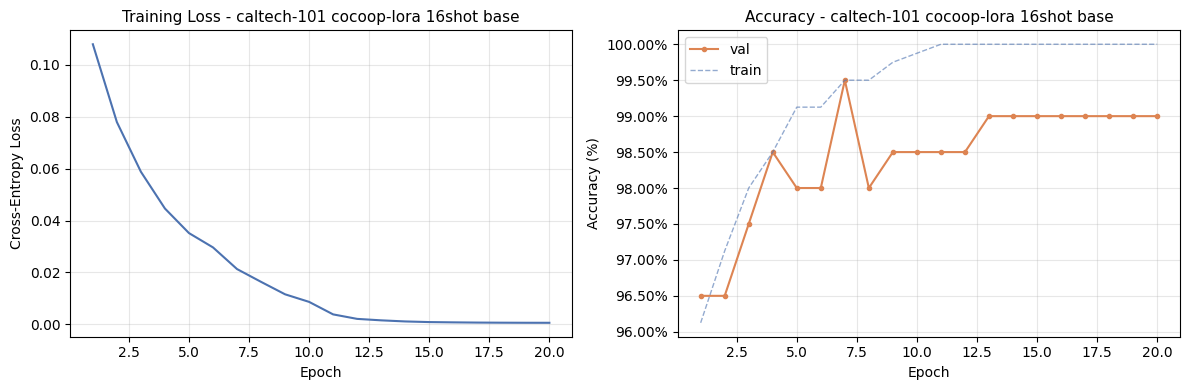

  Saved: curve_caltech-101_cocoop-lora_1shot_base.png


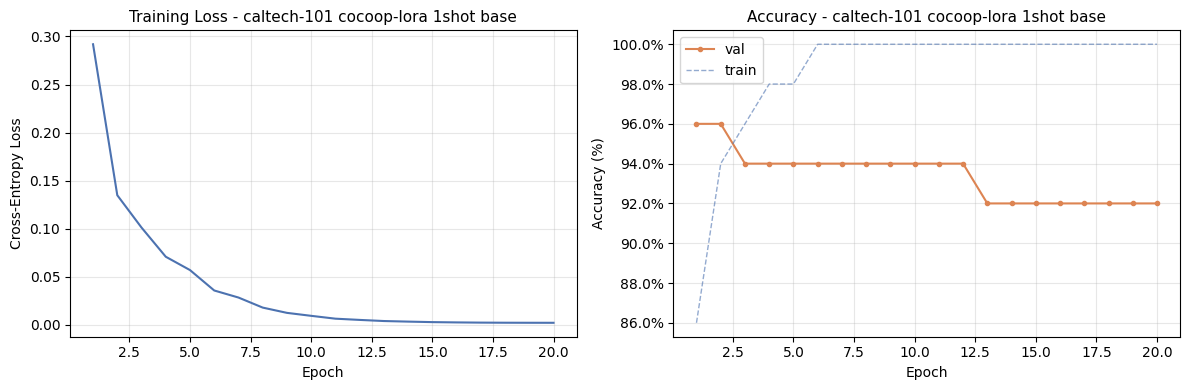

  Saved: curve_caltech-101_cocoop-lora_4shot_base.png


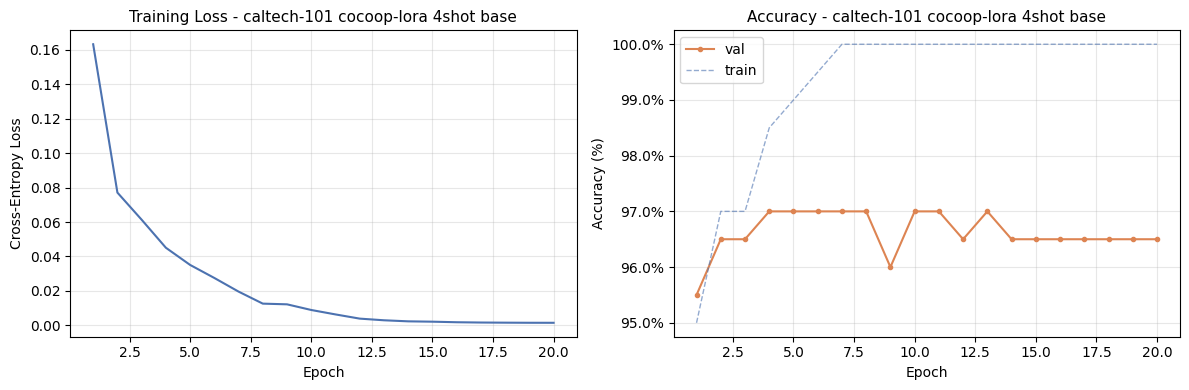

  Saved: curve_caltech-101_cocoop-lora_8shot_base.png


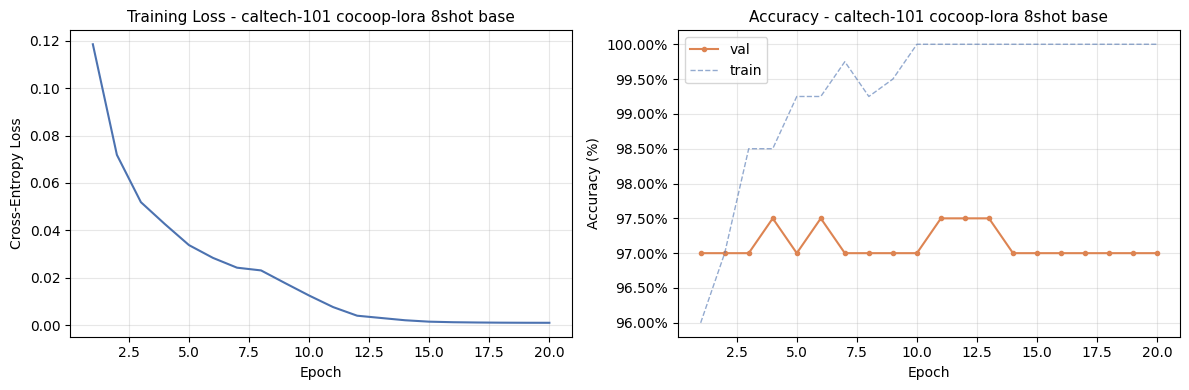

  Saved: curve_caltech-101_cocoop_16shot_base.png


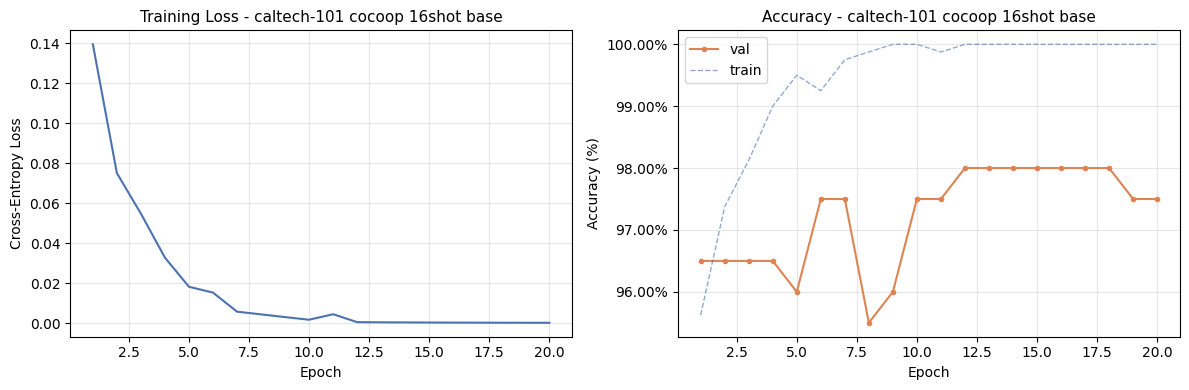

  Saved: curve_caltech-101_cocoop_1shot_base.png


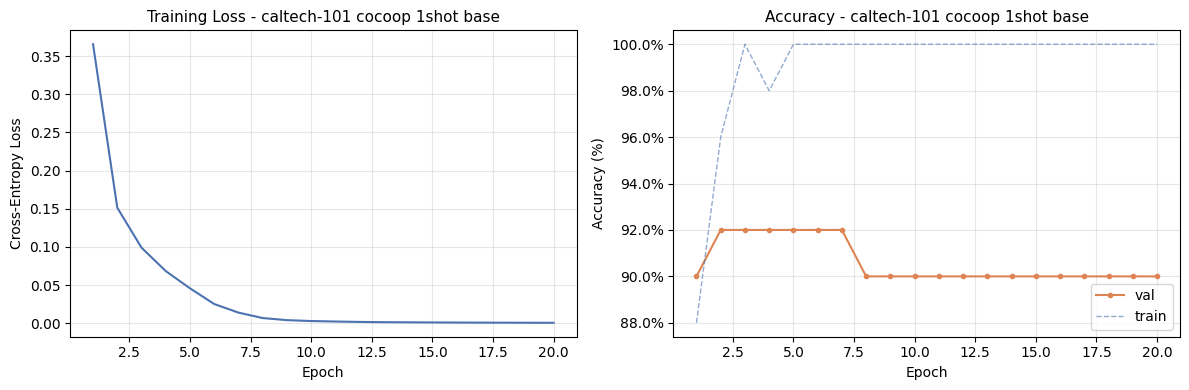

  Saved: curve_caltech-101_cocoop_4shot_base.png


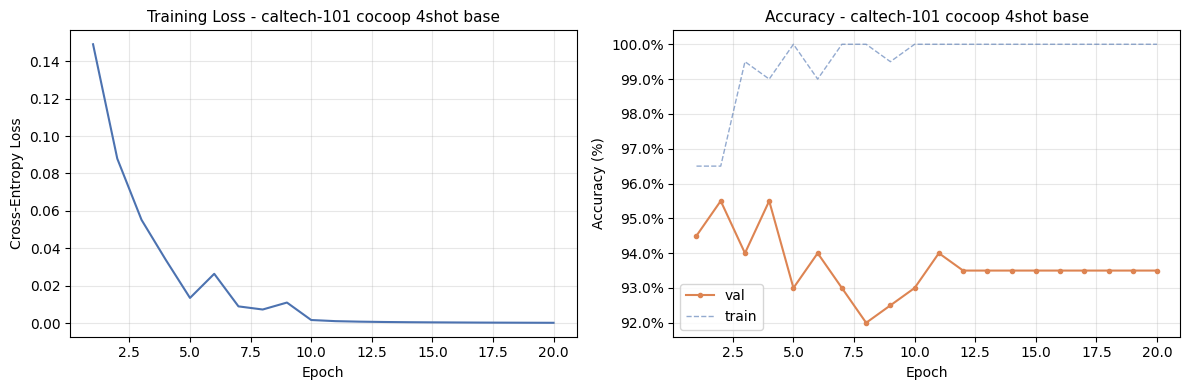

  Saved: curve_caltech-101_cocoop_8shot_base.png


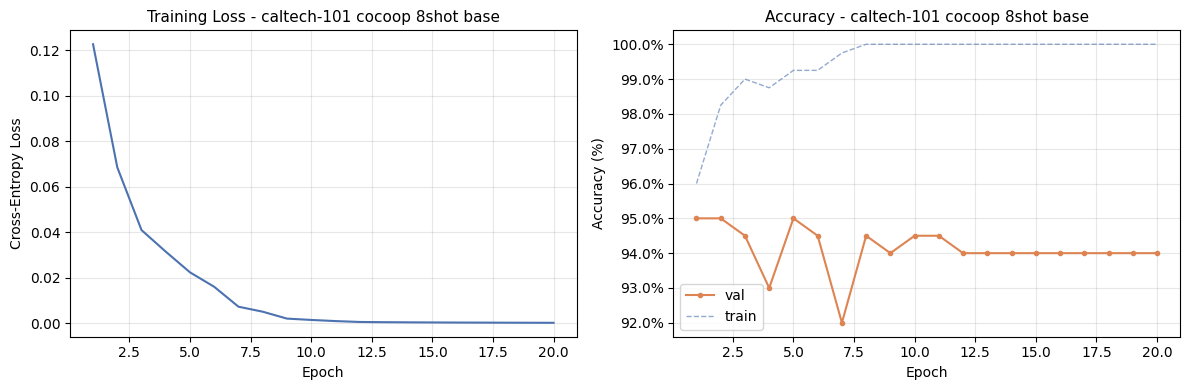

  Saved: curve_caltech-101_lora_16shot_base.png


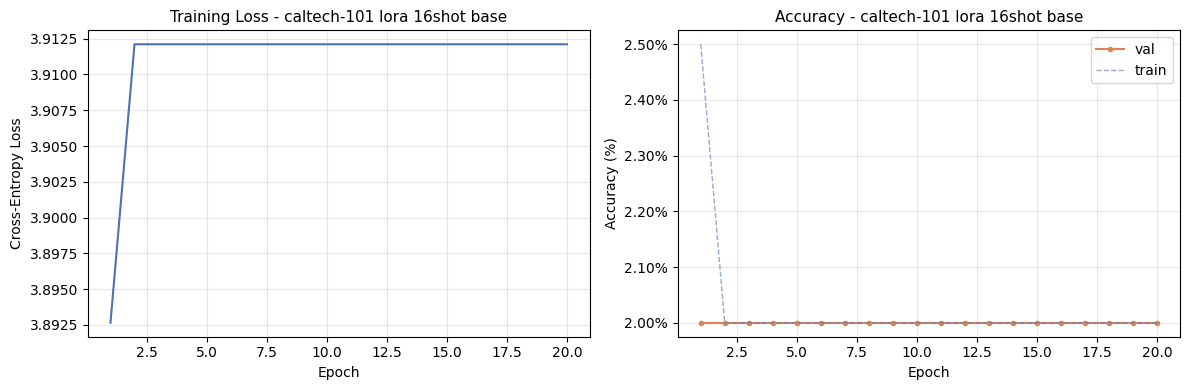

  Saved: curve_caltech-101_lora_1shot_base.png


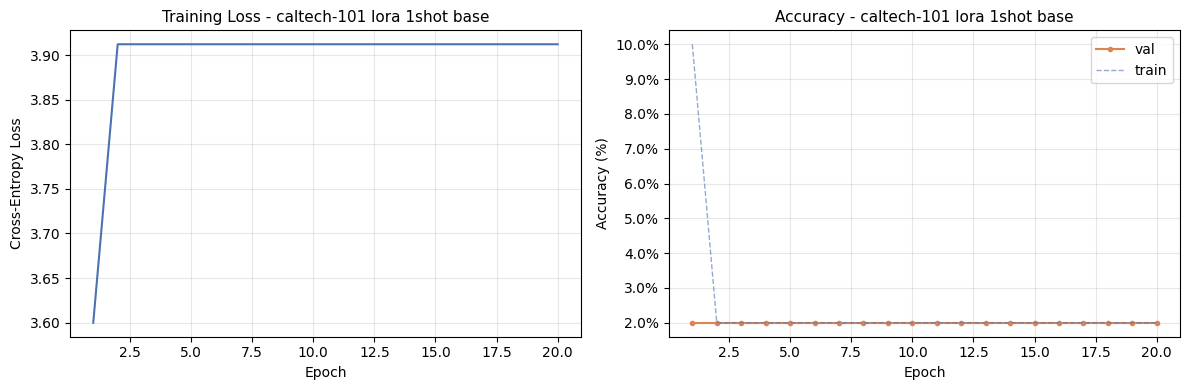

  Saved: curve_caltech-101_lora_4shot_base.png


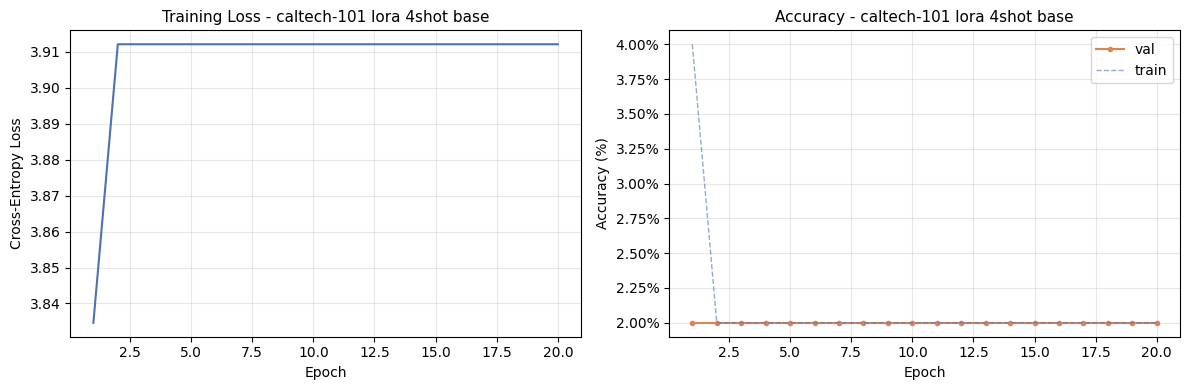

  Saved: curve_caltech-101_lora_8shot_base.png


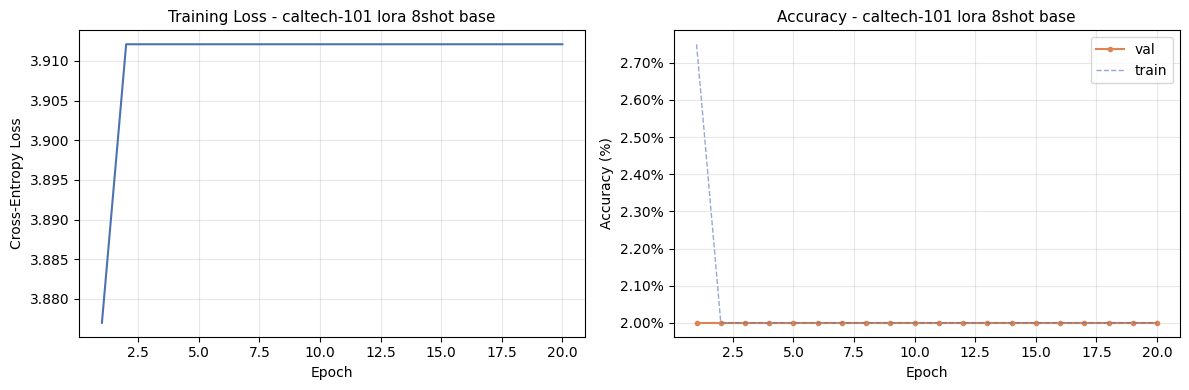

In [22]:
def plot_training_curves(hist_df: pd.DataFrame, title: str, save_path: str = None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(hist_df["epoch"], hist_df["train_loss"], color="#4C72B0", lw=1.5)
    ax1.set_title(f"Training Loss - {title}", fontsize=11)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
    ax1.grid(alpha=0.3)

    ax2.plot(hist_df["epoch"], hist_df["val_acc"],   color="#DD8452", lw=1.5, marker="o", ms=3)
    ax2.plot(hist_df["epoch"], hist_df["train_acc"], color="#4C72B0", lw=1.0, linestyle="--", alpha=0.6, label="train")
    ax2.set_title(f"Accuracy - {title}", fontsize=11)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.legend(["val", "train"]); ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {os.path.basename(save_path)}")
    plt.show()
    plt.close()

# Plot all saved history CSVs
curve_dir = os.path.join(PLOTS_DIR, "training_curves")
os.makedirs(curve_dir, exist_ok=True)

for fname in sorted(os.listdir(CSV_DIR)):
    if not fname.startswith("history_"):
        continue
    if "clip" in fname.lower():
        continue
    stem  = fname.replace("history_", "").replace(".csv", "")
    hdf   = pd.read_csv(os.path.join(CSV_DIR, fname))
    title = stem.replace("_", " ")
    spath = os.path.join(curve_dir, f"curve_{stem}.png")
    plot_training_curves(hdf, title, save_path=spath)

## 20. Base/New Grouped Bar Charts

  Saved: base_new_caltech-101.png


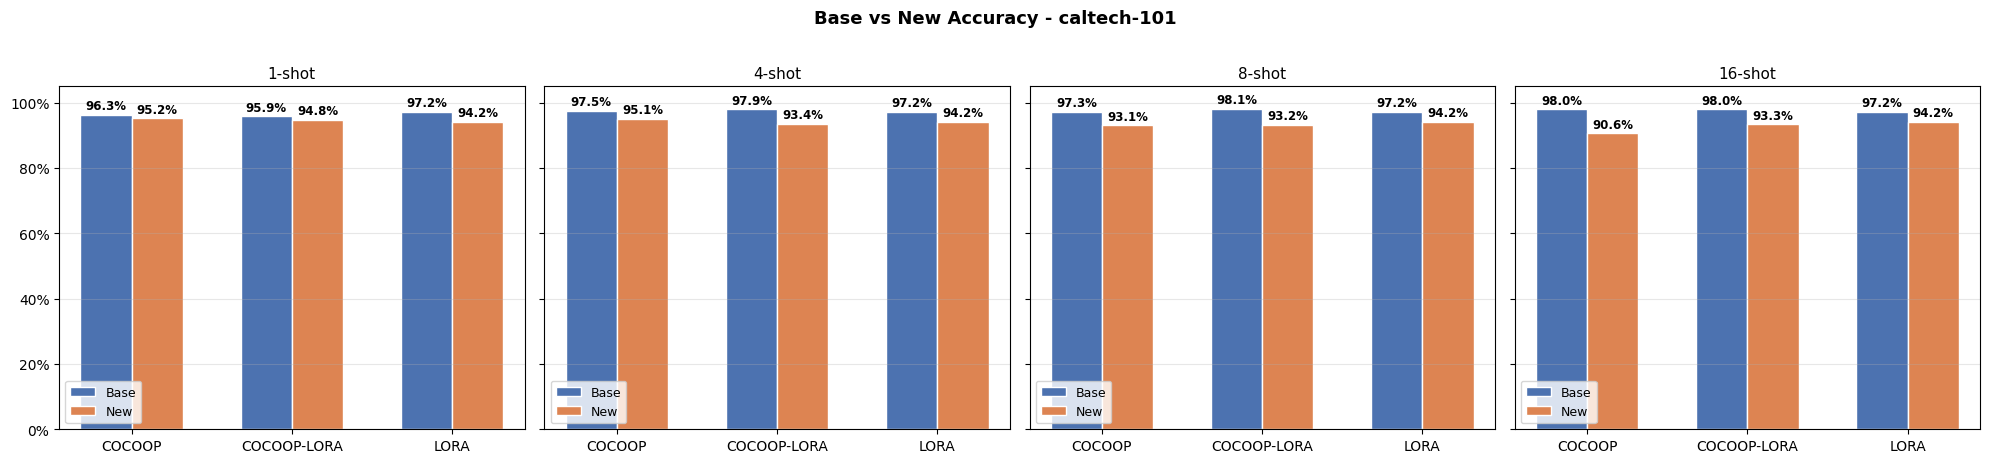

In [23]:
def plot_base_new_for_dataset(df: pd.DataFrame, dataset_name: str, save_dir: str = None):
    methods = ["cocoop", "cocoop-lora", "lora"]
    sub = df[df["dataset"] == dataset_name].copy()
    sub = sub[sub["method"].isin(methods)]
    shots_avail = sorted(sub["shots"].unique())

    fig, axes = plt.subplots(1, len(shots_avail), figsize=(5 * len(shots_avail), 4.5), sharey=True)
    if len(shots_avail) == 1:
        axes = [axes]

    colors = {"Base": "#4C72B0", "New": "#DD8452"}

    for ax, shots in zip(axes, shots_avail):
        s       = sub[sub["shots"] == shots]
        x       = np.arange(len(methods))
        width   = 0.32

        base_vals = [float(s[s["method"] == m]["base_acc"].iloc[0]) for m in methods]
        new_vals  = [float(s[s["method"] == m]["new_acc"].iloc[0])  for m in methods]

        b1 = ax.bar(x - width/2, base_vals, width, label="Base", color=colors["Base"], edgecolor="white")
        b2 = ax.bar(x + width/2, new_vals,  width, label="New",  color=colors["New"],  edgecolor="white")

        for bar in list(b1) + list(b2):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.8,
                    f"{bar.get_height():.1f}%",
                    ha="center", va="bottom", fontsize=8.5, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels([m.upper() for m in methods], fontsize=10)
        ax.set_title(f"{shots}-shot", fontsize=11)
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

    fig.suptitle(f"Base vs New Accuracy - {dataset_name}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"base_new_{dataset_name}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {os.path.basename(path)}")
    plt.show()
    plt.close()

bn_dir = os.path.join(PLOTS_DIR, "base_new")
for ds in DATASETS:
    if ds in results_df["dataset"].values:
        plot_base_new_for_dataset(results_df, ds, save_dir=bn_dir)

## 21. Harmonic Mean Comparison Chart

  Saved: hm_comparison.png


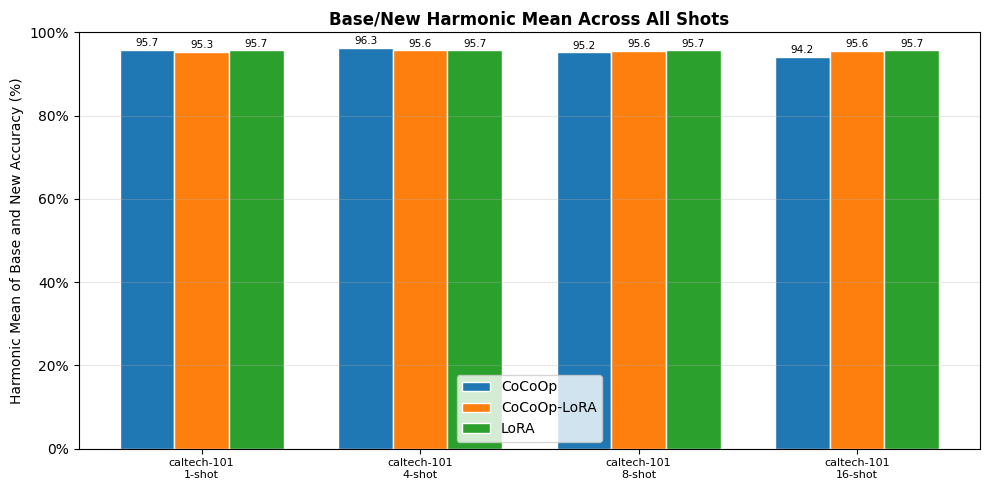

In [24]:
def plot_harmonic_mean_comparison(df: pd.DataFrame, save_path: str = None):
    methods = ["cocoop", "cocoop-lora", "lora"]
    df = df[df["method"].isin(methods)]
    df = df[df["shots"] > 0]

    pivot  = df.pivot_table(index=["dataset", "shots"], columns="method", values="hm")
    labels = [f"{idx[0]}\n{idx[1]}-shot" for idx in pivot.index]
    x      = np.arange(len(labels))
    width  = 0.25

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.9), 5))

    cocoop_vals   = pivot["cocoop"].fillna(np.nan).values
    cocoop_lora_vals = pivot["cocoop-lora"].fillna(np.nan).values
    lora_vals = pivot["lora"].fillna(np.nan).values

    b1 = ax.bar(x - width, cocoop_vals,   width, label="CoCoOp", edgecolor="white")
    b2 = ax.bar(x, cocoop_lora_vals, width, label="CoCoOp-LoRA", edgecolor="white")
    b3 = ax.bar(x + width, lora_vals, width, label="LoRA", edgecolor="white")

    for bars in [b1, b2, b3]:
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.4,
                    f"{bar.get_height():.1f}",
                    ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Harmonic Mean of Base and New Accuracy (%)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title("Base/New Harmonic Mean Across All Shots",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {os.path.basename(save_path)}")
    plt.show()
    plt.close()

plot_harmonic_mean_comparison(
    results_df,
    save_path=os.path.join(PLOTS_DIR, "hm_comparison.png"))

## 22. Summary Results Table

,dataset,shots,CLIP_all_acc,COCOOP_all_acc,COCOOP-LORA_all_acc,LORA_all_acc,CLIP_base_acc,COCOOP_base_acc,COCOOP-LORA_base_acc,LORA_base_acc,CLIP_hm,COCOOP_hm,COCOOP-LORA_hm,LORA_hm,CLIP_new_acc,COCOOP_new_acc,COCOOP-LORA_new_acc,LORA_new_acc
0,caltech-101,0,93.27,NaN,NaN,NaN,97.16,NaN,NaN,NaN,95.66,NaN,NaN,NaN,94.21,NaN,NaN,NaN
1,caltech-101,1,NaN,93.51,92.98,93.27,NaN,96.26,95.87,97.16,NaN,95.72,95.31,95.66,NaN,95.20,94.76,94.21
2,caltech-101,4,NaN,94.65,94.00,93.27,NaN,97.48,97.93,97.16,NaN,96.27,95.64,95.66,NaN,95.09,93.45,94.21
3,caltech-101,8,NaN,93.63,94.08,93.27,NaN,97.29,98.06,97.16,NaN,95.16,95.59,95.66,NaN,93.12,93.23,94.21
4,caltech-101,16,NaN,92.90,93.63,93.27,NaN,98.00,98.00,97.16,NaN,94.16,95.61,95.66,NaN,90.61,93.34,94.21


Summary table saved → /kaggle/working/output/csv/lora_summary_table.csv
Table image saved → /kaggle/working/output/plots/summary_table.png


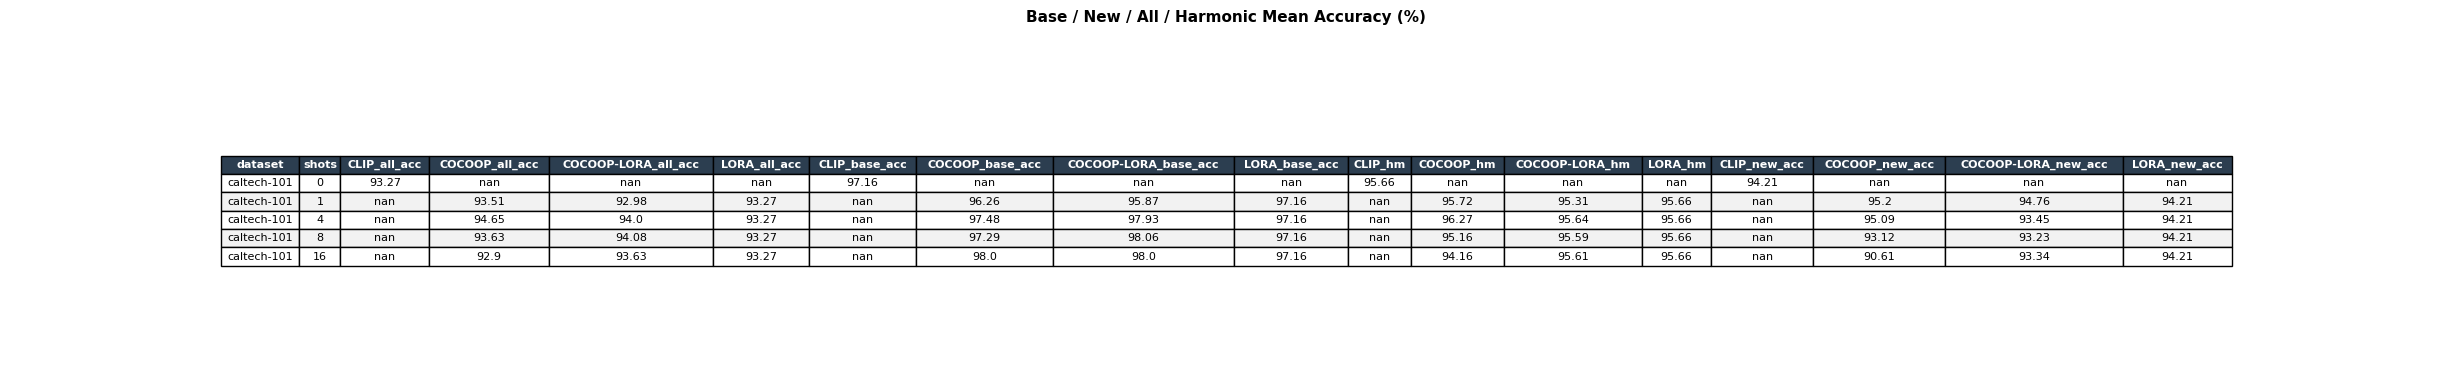

In [25]:
# Display
summary = results_df.copy()
for col in ["base_acc", "new_acc", "all_acc", "hm"]:
    summary[col] = summary[col].round(2)

pivot_table = summary.pivot_table(
    index=["dataset", "shots"],
    columns="method",
    values=["base_acc", "new_acc", "all_acc", "hm"]
)
pivot_table.columns = [f"{m.upper()}_{v}" for v, m in pivot_table.columns]
pivot_table = pivot_table.reset_index()

display(pivot_table)

# Save summary CSV
summary_csv = os.path.join(CSV_DIR, "lora_summary_table.csv")
pivot_table.to_csv(summary_csv, index=False)
print(f"Summary table saved → {summary_csv}")

# Save as PNG (for report)
fig, ax = plt.subplots(figsize=(max(14, len(pivot_table.columns)*1.4),
                                max(4,  len(pivot_table)*0.45 + 1.5)))
ax.axis("off")
tbl = ax.table(
    cellText  = pivot_table.values,
    colLabels = pivot_table.columns,
    cellLoc   = "center",
    loc       = "center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.auto_set_column_width(col=list(range(len(pivot_table.columns))))

# Header styling
for j in range(len(pivot_table.columns)):
    tbl[(0, j)].set_facecolor("#2c3e50")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")

for i in range(1, len(pivot_table) + 1):
    bg = "#f2f2f2" if i % 2 == 0 else "white"
    for j in range(len(pivot_table.columns)):
        tbl[(i, j)].set_facecolor(bg)

ax.set_title("Base / New / All / Harmonic Mean Accuracy (%)",
             fontsize=11, fontweight="bold", pad=14)
plt.tight_layout()
tbl_path = os.path.join(PLOTS_DIR, "summary_table.png")
plt.savefig(tbl_path, dpi=180, bbox_inches="tight")
print(f"Table image saved → {tbl_path}")
plt.show()
plt.close()

## 23. Per-Shot Accuracy Line Chart

  Saved: shots_hm.png


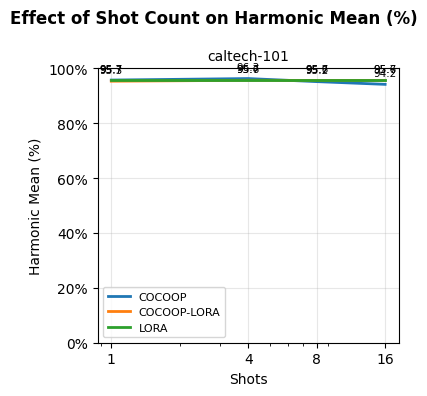

  Saved: shots_base.png


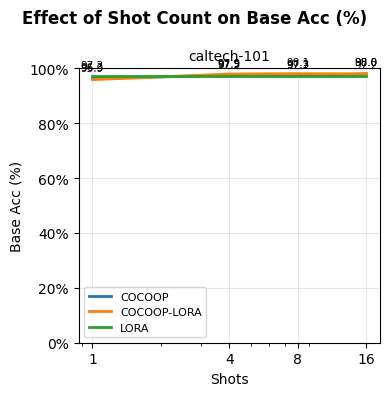

  Saved: shots_new.png


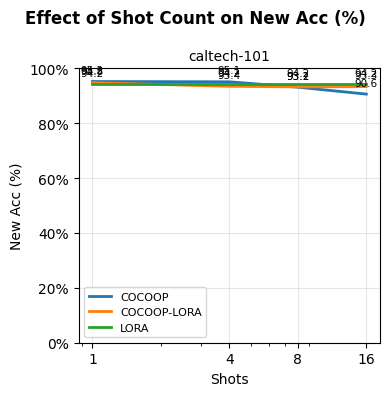

  Saved: shots_all.png


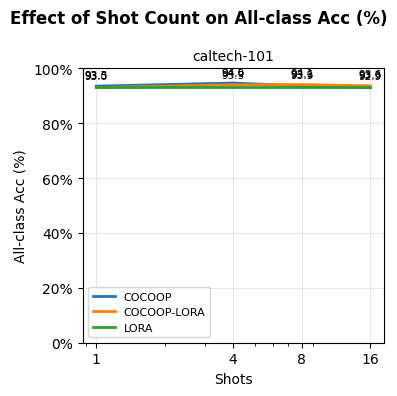

In [26]:
def plot_shots_progression(df: pd.DataFrame, metric: str = "hm", save_path: str = None):
    """Line chart: x=shots, y=metric, one line per dataset×method."""
    methods = ["cocoop", "cocoop-lora", "lora"]
    df = df[df["method"].isin(methods)]
    df = df[df["shots"] > 0]

    fig, axes = plt.subplots(1, len(DATASETS), figsize=(4 * len(DATASETS), 4), sharey=True)

    metric_label = {"hm": "Harmonic Mean (%)", "base_acc": "Base Acc (%)", "new_acc": "New Acc (%)", "all_acc": "All-class Acc (%)"}

    if len(DATASETS) == 1:
        axes = [axes]
        for ax, ds in zip(axes, DATASETS):
            sub = df[df["dataset"] == ds]
            for method in methods:
                m_sub = sub[sub["method"] == method].sort_values("shots")
                if m_sub.empty:
                    continue
                ax.plot(m_sub["shots"], m_sub[metric], lw=2, ms=7, label=method.upper())
                for _, row in m_sub.iterrows():
                    ax.annotate(f"{row[metric]:.1f}",
                                (row["shots"], row[metric]),
                                textcoords="offset points", xytext=(0, 6),
                                ha="center", fontsize=7.5)

            ax.set_title(ds, fontsize=10)
            ax.set_xlabel("Shots"); ax.set_xscale("log")
            ax.set_xticks(SHOTS_LIST); ax.get_xaxis().set_major_formatter(mtick.ScalarFormatter())
            ax.set_ylim(0, 100)
            ax.yaxis.set_major_formatter(mtick.PercentFormatter())
            ax.legend(fontsize=8); ax.grid(alpha=0.3)

        axes[0].set_ylabel(metric_label.get(metric, metric))
        fig.suptitle(f"Effect of Shot Count on {metric_label.get(metric, metric)}",
                    fontsize=12, fontweight="bold")
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"  Saved: {os.path.basename(save_path)}")
        plt.show()
        plt.close()

for metric, fname in [("hm", "shots_hm.png"), ("base_acc", "shots_base.png"), ("new_acc", "shots_new.png"), ("all_acc", "shots_all.png")]:
    plot_shots_progression(results_df, metric=metric,
                           save_path=os.path.join(PLOTS_DIR, fname))

## 24. Plot Experiment Time

  Saved: time_comparison.png


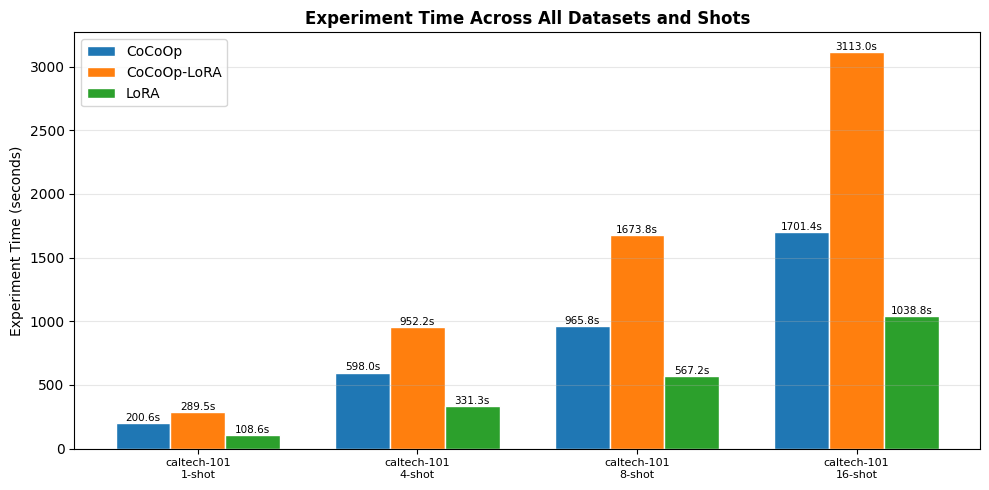

In [27]:
def plot_experiment_time_comparison(df: pd.DataFrame, save_path: str = None):
    methods = ["cocoop", "cocoop-lora", "lora"]
    df = df[df["method"].isin(methods)]
    df = df[df["shots"] > 0]

    pivot  = df.pivot_table(index=["dataset", "shots"], columns="method", values="time")
    labels = [f"{idx[0]}\n{idx[1]}-shot" for idx in pivot.index]
    x      = np.arange(len(labels))
    width  = 0.25

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.9), 5))

    cocoop_vals   = pivot["cocoop"].fillna(np.nan).values
    cocoop_lora_vals = pivot["cocoop-lora"].fillna(np.nan).values
    lora_vals = pivot["lora"].fillna(np.nan).values

    b1 = ax.bar(x - width, cocoop_vals,   width, label="CoCoOp", edgecolor="white")
    b2 = ax.bar(x, cocoop_lora_vals, width, label="CoCoOp-LoRA", edgecolor="white")
    b3 = ax.bar(x + width, lora_vals, width, label="LoRA", edgecolor="white")

    for bars in [b1, b2, b3]:
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.4,
                        f"{bar.get_height():.1f}s",
                        ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Experiment Time (seconds)")
    ax.set_title("Experiment Time Across All Datasets and Shots",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {os.path.basename(save_path)}")
    plt.show()
    plt.close()

plot_experiment_time_comparison(
    results_df,
    save_path=os.path.join(PLOTS_DIR, "time_comparison.png"))

## 25. CLIP Attention Map Visualisation


Attention maps - caltech-101
Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)
  Saved: attn_cocoop_caltech-101.png


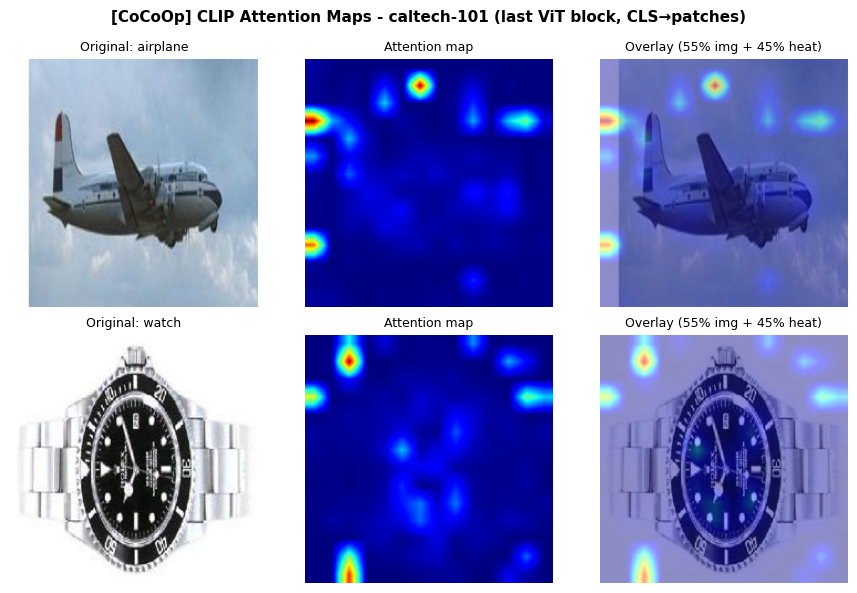

Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)
  Saved: attn_cocoop-lora_caltech-101.png


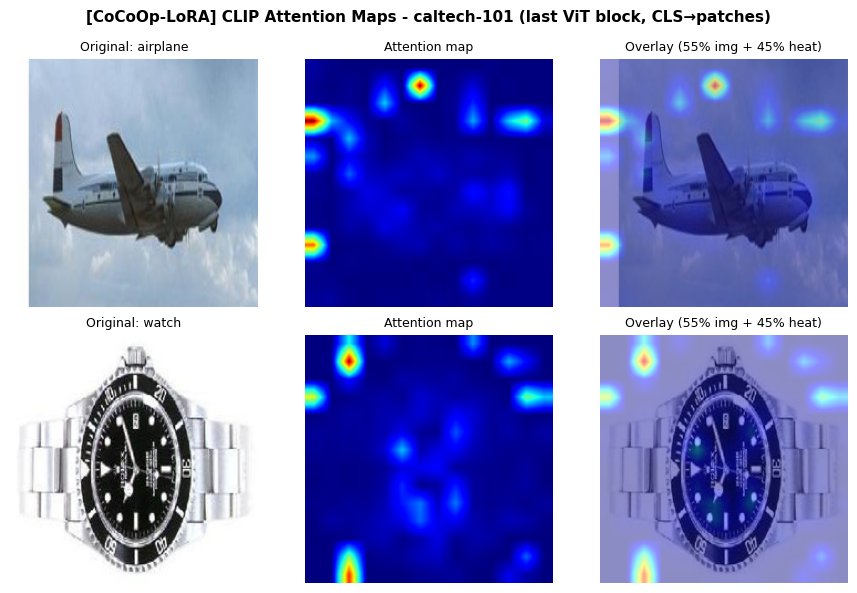

Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)
Injected LoRA into: resblocks.0.mlp.c_fc
Injected LoRA into: resblocks.0.mlp.c_proj
Injected LoRA into: resblocks.1.mlp.c_fc
Injected LoRA into: resblocks.1.mlp.c_proj
Injected LoRA into: resblocks.2.mlp.c_fc
Injected LoRA into: resblocks.2.mlp.c_proj
Injected LoRA into: resblocks.3.mlp.c_fc
Injected LoRA into: resblocks.3.mlp.c_proj
Injected LoRA into: resblocks.4.mlp.c_fc
Injected LoRA into: resblocks.4.mlp.c_proj
Injected LoRA into: resblocks.5.mlp.c_fc
Injected LoRA into: resblocks.5.mlp.c_proj
Injected LoRA into: resblocks.6.mlp.c_fc
Injected LoRA into: resblocks.6.mlp.c_proj
Injected LoRA into: resblocks.7.mlp.c_fc
Injected LoRA into: resblocks.7.mlp.c_proj
Injected LoRA into: resblocks.8.mlp.c_fc
Injected LoRA into: resblocks.8.mlp.c_proj
Injected LoRA into: resblocks.9.mlp.c_fc
Injected LoRA

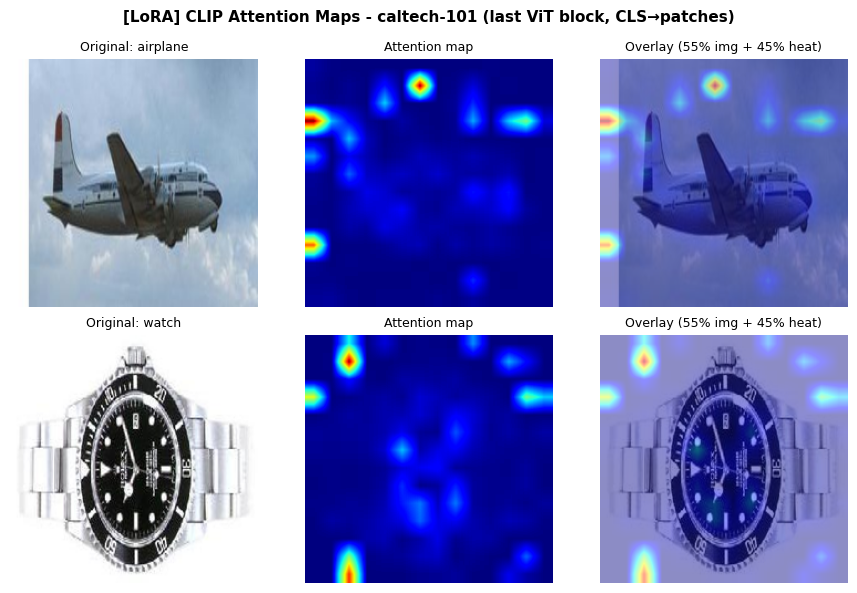

Loaded      : ViT-B/16
vis_dim     : 512
ctx_dim     : 512
MetaNet     : 512 → 32 → 512  (vis_dim//16 per paper)
dtype       : torch.float16  (preserved natively for GPU fp16 compatibility)
  Saved: attn_clip_caltech-101.png


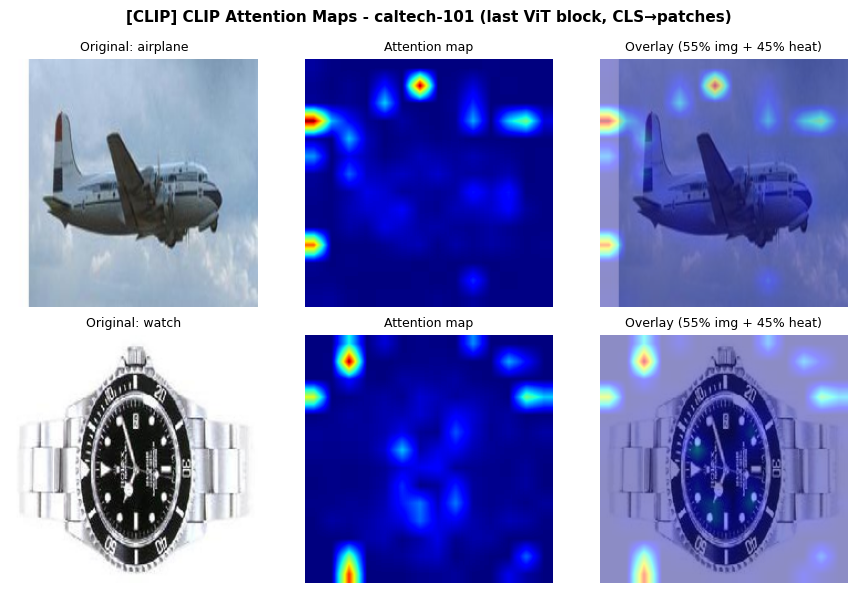

In [28]:
def get_clip_attention_map(model, image_tensor: torch.Tensor) -> np.ndarray:
    """
    Extract CLS-token attention from CLIP's last visual transformer block.

    Strategy: register a forward hook on the last ResidualAttentionBlock's
    MultiheadAttention module. Since the standard CLIP forward discards
    attention weights, the hook re-runs the MHA with need_weights=True.

    Returns:
        attn_map : (14, 14) numpy array, values in [0, 1]
    """
    visual = model.image_encoder if hasattr(model, "image_encoder") else model.clip_model.visual
    last_block  = visual.transformer.resblocks[-1]
    attn_store  = {}

    def hook_fn(module, inp, output):
        # inp[0]: (seq_len, 1, embed_dim) — x after LayerNorm
        x_in = inp[0]
        with torch.no_grad():
            # Re-run MHA with need_weights=True to get attention weights
            _, weights = F.multi_head_attention_forward(
                query               = x_in,
                key                 = x_in,
                value               = x_in,
                embed_dim_to_check  = x_in.shape[-1],
                num_heads           = module.num_heads,
                in_proj_weight      = module.in_proj_weight,
                in_proj_bias        = module.in_proj_bias,
                bias_k              = None,
                bias_v              = None,
                add_zero_attn       = False,
                dropout_p           = 0.0,
                out_proj_weight     = module.out_proj.weight,
                out_proj_bias       = module.out_proj.bias,
                training            = False,
                need_weights        = True,
                average_attn_weights= True,
            )
        attn_store["weights"] = weights.detach().cpu()  # (1, seq_len, seq_len)

    handle = last_block.attn.register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model.image_encoder(image_tensor.unsqueeze(0).to(DEVICE))

    handle.remove()

    weights = attn_store["weights"][0]  # (seq_len, seq_len)
    # Row 0 = CLS token attending to all patches (skip CLS→CLS at index 0)
    cls_attn = weights[0, 1:].numpy()   # (196,)

    # Normalise and reshape to spatial grid
    cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
    n_side   = int(cls_attn.shape[0] ** 0.5)  # 14 for ViT-B/16
    return cls_attn.reshape(n_side, n_side)

def visualise_attention(dataset_name: str, n_samples: int = 2):
    """
    Display attention maps for n_samples random test images from a dataset.
    Each row: original image | attention heatmap | overlay.
    """
    _, split_path, image_root = get_dataset_paths(dataset_name)
    with open(split_path, "r") as f:
        split = json.load(f)

    classnames = sorted({r[2] for r in split["train"]})
    test_items = [(os.path.join(image_root, r[0]), r[2]) for r in split["test"]]
    rng        = random.Random(SEED)
    samples    = rng.sample(test_items, min(n_samples, len(test_items)))

    to_tensor = preprocess  # CLIP preprocess already handles resize/crop/normalise
    
    method_name = {"cocoop": "CoCoOp", "cocoop-lora": "CoCoOp-LoRA", "lora": "LoRA", "clip": "CLIP"}
    
    for method in ["cocoop", "cocoop-lora", "lora", "clip"]:
        model = build_model(method, classnames)
        model.eval()
        
        fig, axes = plt.subplots(len(samples), 3, figsize=(9, 3 * len(samples)))
        if len(samples) == 1:
            axes = [axes]
            
        for row_axes, (impath, classname) in zip(axes, samples):
            try:
                pil_img      = Image.open(impath).convert("RGB").resize((224, 224))
                img_tensor   = to_tensor(pil_img).to(DEVICE)
                img_tensor = img_tensor.to(model.dtype)
                attn_map     = get_clip_attention_map(model, img_tensor)
    
                # Upsample attention map to 224×224
                attn_up = np.array(
                    Image.fromarray((attn_map * 255).astype(np.uint8)).resize(
                        (224, 224), Image.Resampling.BILINEAR)) / 255.0
    
                row_axes[0].imshow(pil_img)
                row_axes[0].set_title(f"Original: {classname}", fontsize=9)
                row_axes[0].axis("off")
    
                row_axes[1].imshow(attn_up, cmap="jet", vmin=0, vmax=1)
                row_axes[1].set_title("Attention map", fontsize=9)
                row_axes[1].axis("off")
    
                overlay = np.array(pil_img).astype(float) / 255.0
                heat    = cm.jet(attn_up)[:, :, :3]
                blended = 0.55 * overlay + 0.45 * heat
                blended = np.clip(blended, 0, 1)
                row_axes[2].imshow(blended)
                row_axes[2].set_title("Overlay (55% img + 45% heat)", fontsize=9)
                row_axes[2].axis("off")
            except Exception as e:
                for ax in row_axes:
                    ax.axis("off")
                print(f"  Warning: skipped {impath} - {e}")
    
        fig.suptitle(f"[{method_name[method]}] CLIP Attention Maps - {dataset_name} (last ViT block, CLS→patches)",
                     fontsize=11, fontweight="bold")
        plt.tight_layout()
        save_path = os.path.join(attn_dir, f"attn_{method}_{dataset_name}.png")
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {os.path.basename(save_path)}")
        plt.show()
        plt.close()

attn_dir = os.path.join(PLOTS_DIR, "attention_maps")
os.makedirs(attn_dir, exist_ok=True)

for ds in DATASETS:
    print(f"\nAttention maps - {ds}")
    visualise_attention(
        ds, n_samples=2)